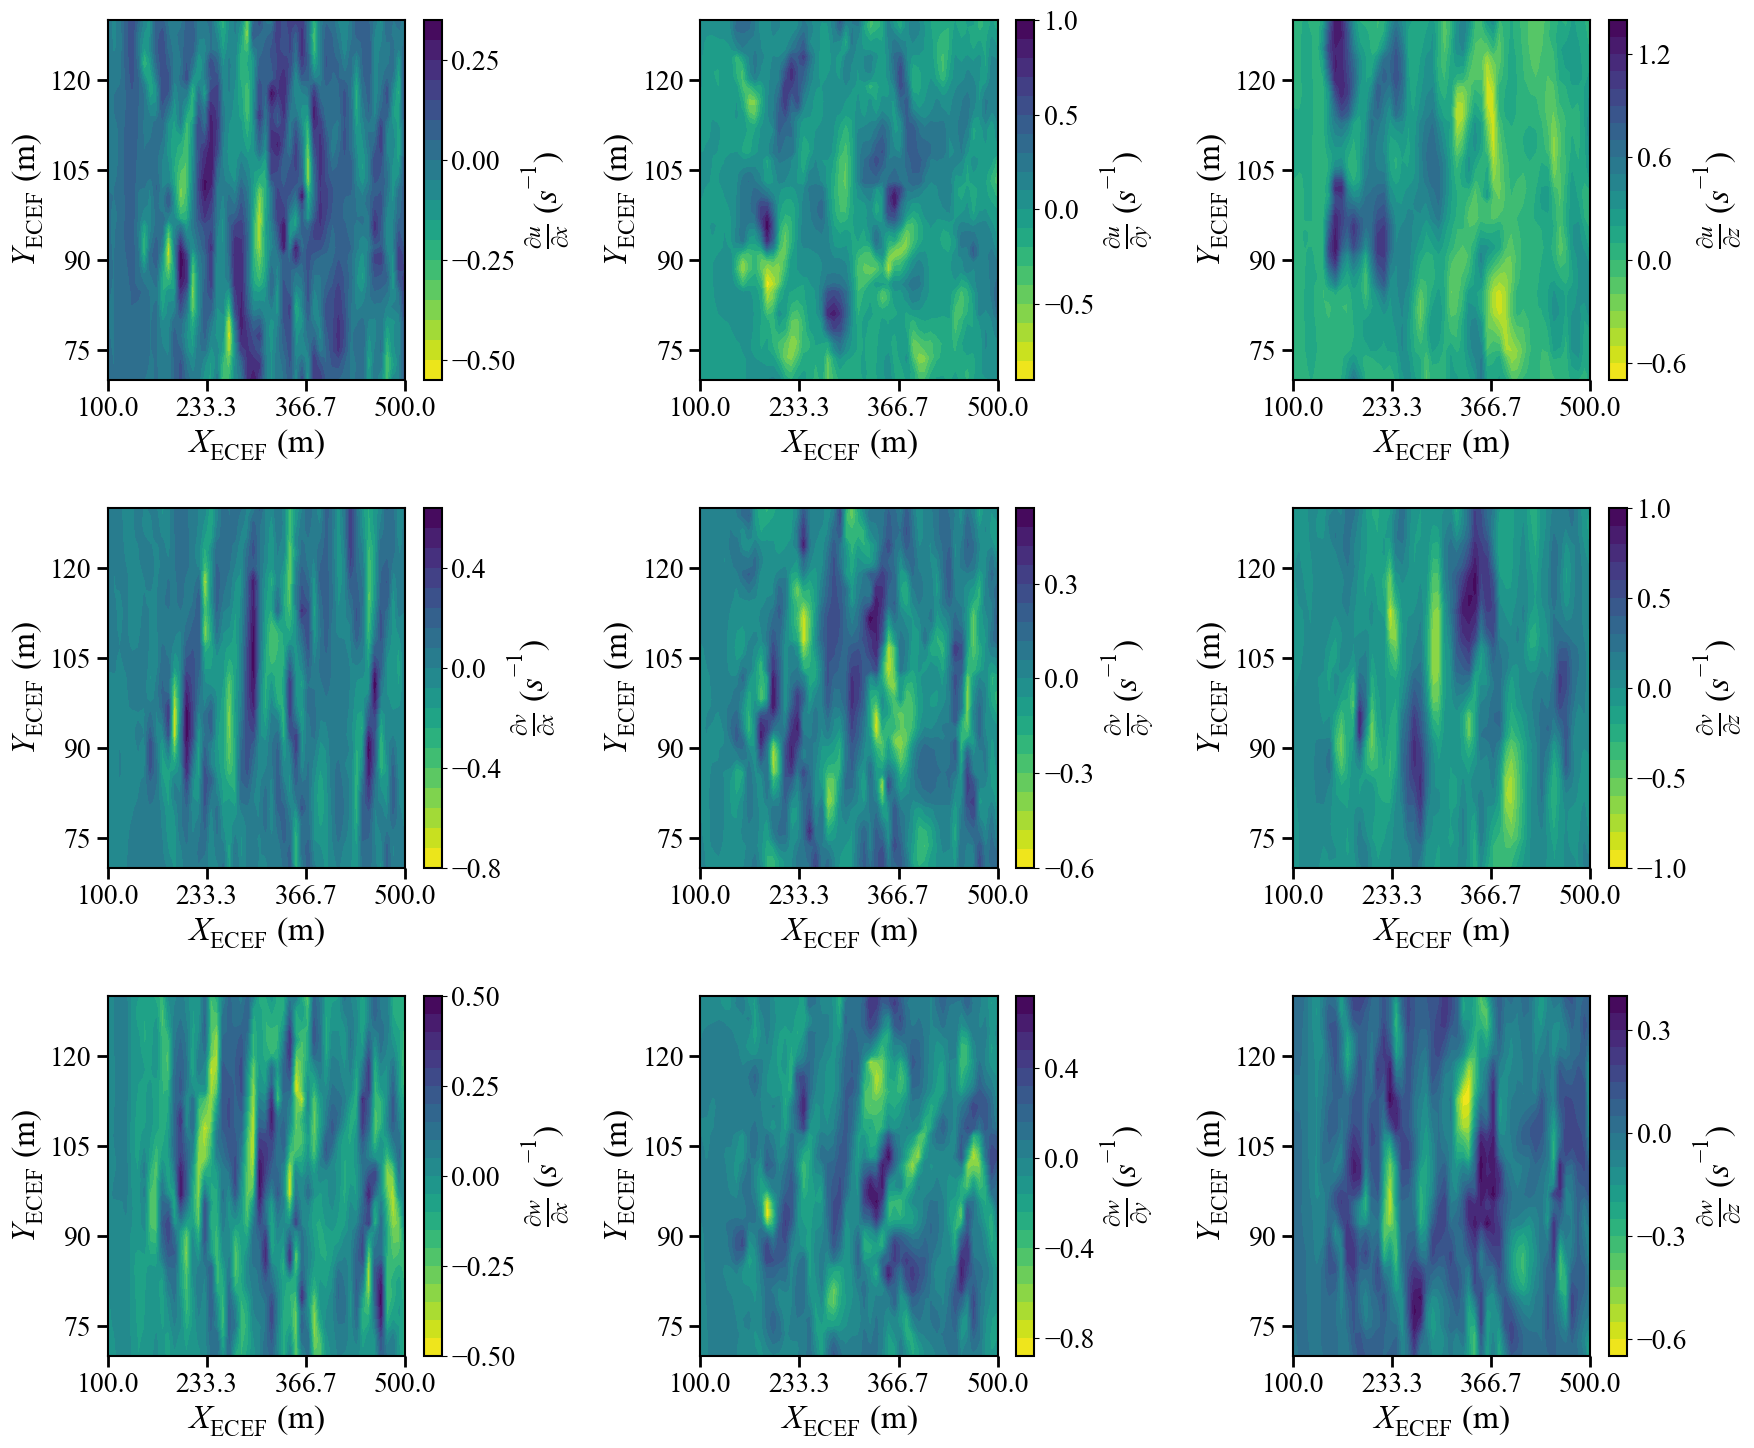

In [ ]:
import pyvista as pv
import numpy as np
import matplotlib.pyplot as plt
from nl_vlm import WindField

x_positions = np.linspace(100, 500, 50)
y_positions = np.linspace(70, 130, 50)
z_height = 50  # Reference height
X, Y = np.meshgrid(x_positions, y_positions)

# Initialize arrays for all 9 Jacobian components
dudx_values = np.zeros_like(X)
dudy_values = np.zeros_like(X)
dudz_values = np.zeros_like(X)
dvdx_values = np.zeros_like(X)
dvdy_values = np.zeros_like(X)
dvdz_values = np.zeros_like(X)
dwdx_values = np.zeros_like(X)
dwdy_values = np.zeros_like(X)
dwdz_values = np.zeros_like(X)

mesh = pv.read(r"../../wind/vtk_resampled/resampled_75.vtk")


wind_field = WindField(mesh)

for i, x_pos in enumerate(x_positions):
    for j, y_pos in enumerate(y_positions):
        # Get Jacobian at this point
        target_coords = [x_pos, y_pos, z_height]
        jacobian_matrix = wind_field.get_jacobian_at_point(target_coords)
        
        # Extract components from the 3x3 Jacobian matrix
        dudx_values[j, i] = jacobian_matrix[0, 0]
        dudy_values[j, i] = jacobian_matrix[0, 1]
        dudz_values[j, i] = jacobian_matrix[0, 2]
        
        dvdx_values[j, i] = jacobian_matrix[1, 0]
        dvdy_values[j, i] = jacobian_matrix[1, 1]
        dvdz_values[j, i] = jacobian_matrix[1, 2]
        
        dwdx_values[j, i] = jacobian_matrix[2, 0]
        dwdy_values[j, i] = jacobian_matrix[2, 1]
        dwdz_values[j, i] = jacobian_matrix[2, 2]

plt.rcParams.update({
    "font.family": "serif", "font.serif": ["Times New Roman"],
    "font.size": 24, "axes.labelsize": 24,
    "xtick.labelsize": 24, "ytick.labelsize": 24,
    "axes.linewidth": 1.5, "axes.grid": False,
    "mathtext.fontset": "custom",
    "mathtext.rm": "Times New Roman",
    "mathtext.it": "Times New Roman:italic",
})

# Create 3x3 subplot for the Jacobian matrix
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes_flat = axes.flatten()

# Jacobian components and their labels
jacobian_data = [
    (dudx_values, r'$\frac{\partial u}{\partial x}$', r'$\frac{\partial u}{\partial x}$ $(s^{-1})$'),
    (dudy_values, r'$\frac{\partial u}{\partial y}$', r'$\frac{\partial u}{\partial y}$ $(s^{-1})$'), 
    (dudz_values, r'$\frac{\partial u}{\partial z}$', r'$\frac{\partial u}{\partial z}$ $(s^{-1})$'),
    (dvdx_values, r'$\frac{\partial v}{\partial x}$', r'$\frac{\partial v}{\partial x}$ $(s^{-1})$'),
    (dvdy_values, r'$\frac{\partial v}{\partial y}$', r'$\frac{\partial v}{\partial y}$ $(s^{-1})$'),
    (dvdz_values, r'$\frac{\partial v}{\partial z}$', r'$\frac{\partial v}{\partial z}$ $(s^{-1})$'),
    (dwdx_values, r'$\frac{\partial w}{\partial x}$', r'$\frac{\partial w}{\partial x}$ $(s^{-1})$'),
    (dwdy_values, r'$\frac{\partial w}{\partial y}$', r'$\frac{\partial w}{\partial y}$ $(s^{-1})$'),
    (dwdz_values, r'$\frac{\partial w}{\partial z}$', r'$\frac{\partial w}{\partial z}$ $(s^{-1})$')
]

# Plot each Jacobian component
for idx, (data, label, cbar_label) in enumerate(jacobian_data):
    ax = axes_flat[idx]
    
    contour = ax.contourf(X, Y, data, levels=20, cmap='viridis_r')

    ax.set_xlabel(r'$X_{\mathrm{ECEF}}$ (m)')
    ax.set_ylabel(r'$Y_{\mathrm{ECEF}}$ (m)')
    
    cbar = plt.colorbar(contour, ax=ax, label=cbar_label)
    cbar.set_label(cbar_label, fontsize=24) 
    cbar.locator = plt.MaxNLocator(4)
    cbar.update_ticks()
    cbar.ax.tick_params(labelsize=20)
    
    ax.tick_params(axis='both', which='major', length=8, width=2, labelsize=20)
    ax.xaxis.set_major_locator(plt.LinearLocator(4))
    ax.yaxis.set_major_locator(plt.MaxNLocator(5))

plt.tight_layout()
plt.show()